# 切口 A 前置验证 — Cohort base / 假死分布 / 双 12 噪声

**目标**:在动手做切口 A(假死用户识别)之前,用数据验证三个关键问题,让后续的阈值
设定、对照组选取、观察期定义都有数据支撑,不靠拍脑袋。

## 三个待验证问题

| # | 问题 | 验证方法 |
|---|---|---|
| 1 | cohort base 选 Day 1 还是 Day 1-2 内有行为的用户? | 算三种候选定义下的用户数,比对差异 |
| 2 | 假死用户的阈值应该怎么切? | 看 cohort 用户在 Day 3-9 的总行为数分布形态 |
| 3 | 双 12 影响从哪天开始?(是 Day 8-9,还是更早) | 看每日 buy 占比、cohort 用户回流情况 |

## 不做

- 不做切口 A 本身的分析(假死 vs 活跃对比、聚类、画像)
- 不下"假死用户的最终定义"。这个 notebook 只产出"用来支撑决策的数据"


## 0. 环境与数据加载

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

PARQUET_PATH = Path('../data/processed/DWD/user_behavior_clean.parquet').resolve()
print(f'DWD 文件: {PARQUET_PATH}')
print(f'文件存在: {PARQUET_PATH.exists()}')

con = duckdb.connect()

# 注册视图,带 event_date 衍生字段(方便日期维度查询)
con.execute(f"""
CREATE OR REPLACE VIEW ub AS
SELECT
    user_id, item_id, category_id, behavior_type, timestamp,
    CAST(to_timestamp(timestamp) AS DATE) AS event_date
FROM '{PARQUET_PATH.as_posix()}'
""")

print('视图 ub 已建立')
con.sql('SELECT COUNT(*) AS total_rows, COUNT(DISTINCT user_id) AS total_users FROM ub').show()

DWD 文件: D:\IndividualProject\留存分析项目\data\processed\DWD\user_behavior_clean.parquet
文件存在: True
视图 ub 已建立
┌────────────┬─────────────┐
│ total_rows │ total_users │
│   int64    │    int64    │
├────────────┼─────────────┤
│  100095231 │      987991 │
└────────────┴─────────────┘



---

## Part 1:Cohort base 候选对比

三种候选定义:

| 候选 | 定义 |
|---|---|
| **C1. Day 1 only** | 在 2017-11-25 有任何行为的用户 |
| **C2. Day 1-2 并集** | 在 2017-11-25 或 2017-11-26 有任何行为的用户(推荐) |
| **C3. Day 1-2 首次出现** | 首次出现日 ∈ {2017-11-25, 2017-11-26} |

C2 和 C3 的差别:
- C2 包括"Day 1 出现 + Day 2 又来"和"Day 1 没来,Day 2 才来"两类
- C3 也包括上述两类,但**两者其实等价**(因为我们的数据从 Day 1 开始,Day 2 之前没有更早的天)

C2 ≡ C3 在我们这个 9 天窗口里。先验证一下。

In [2]:
# 三种候选 cohort 的用户数
con.sql("""
SELECT
    'C1. Day 1 only'                 AS cohort_name,
    COUNT(DISTINCT user_id)          AS users
FROM ub
WHERE event_date = DATE '2017-11-25'

UNION ALL

SELECT
    'C2. Day 1-2 内有行为'            AS cohort_name,
    COUNT(DISTINCT user_id)          AS users
FROM ub
WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')

UNION ALL

SELECT
    'C3. Day 1-2 首次出现'            AS cohort_name,
    COUNT(DISTINCT user_id)          AS users
FROM (
    SELECT user_id, MIN(event_date) AS first_date
    FROM ub
    GROUP BY user_id
)
WHERE first_date IN (DATE '2017-11-25', DATE '2017-11-26')
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────┬────────┐
│     cohort_name      │ users  │
│       varchar        │ int64  │
├──────────────────────┼────────┤
│ C1. Day 1 only       │ 706641 │
│ C2. Day 1-2 内有行为 │ 864829 │
│ C3. Day 1-2 首次出现 │ 864829 │
└──────────────────────┴────────┘



### Part 1.1:看一下 C1 和 C2 之间增量来自哪里

In [3]:
# C2 - C1 的差额 = "Day 2 才第一次出现的用户"
# 也就是 Day 2 出现 但 Day 1 没出现
con.sql("""
WITH day1 AS (SELECT DISTINCT user_id FROM ub WHERE event_date = DATE '2017-11-25'),
     day2 AS (SELECT DISTINCT user_id FROM ub WHERE event_date = DATE '2017-11-26')
SELECT
    (SELECT COUNT(*) FROM day1)                                          AS only_day1_or_overlap,
    (SELECT COUNT(*) FROM day2)                                          AS only_day2_or_overlap,
    (SELECT COUNT(*) FROM day1 INNER JOIN day2 USING(user_id))           AS day1_AND_day2,
    (SELECT COUNT(*) FROM day2 WHERE user_id NOT IN (SELECT user_id FROM day1))  AS only_day2_new
""").show()

┌──────────────────────┬──────────────────────┬───────────────┬───────────────┐
│ only_day1_or_overlap │ only_day2_or_overlap │ day1_AND_day2 │ only_day2_new │
│        int64         │        int64         │     int64     │     int64     │
├──────────────────────┼──────────────────────┼───────────────┼───────────────┤
│               706641 │               715516 │        557328 │        158188 │
└──────────────────────┴──────────────────────┴───────────────┴───────────────┘



**解读要点**:
- `day1_AND_day2`:Day 1 和 Day 2 都出现的用户(重叠区)
- `only_day2_new`:Day 1 没出现、Day 2 才第一次出现的"新增"用户
- C2 ≈ Day 1 用户 + only_day2_new

---

## Part 2:假死的初步分布探索

对推荐方案 **C2(Day 1-2 内有行为的用户)**,看他们在 **Day 3-9(2017-11-27 ~ 12-03)**
的总行为数分布。

这个分布会告诉我们:
- 有多少人完全 0 行为(候选"严格版"假死定义)
- 有多少人极少行为(候选"中等版"定义)
- 分位数分布是什么形态,决定要不要切 3 档、5 档还是别的

注意:Part 3 还要验证 Day 8-9 双 12 噪声问题,如果验证后发现 Day 8-9 应剔除,
这里的分布要重做一次(限制观察期到 Day 3-7)。

In [4]:
# 对 C2 cohort 用户,统计 Day 3-9 总行为数

cohort_activity = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
),
day3_9_activity AS (
    SELECT user_id, COUNT(*) AS day3_9_actions
    FROM ub
    WHERE event_date BETWEEN DATE '2017-11-27' AND DATE '2017-12-03'
    GROUP BY user_id
)
SELECT
    c.user_id,
    COALESCE(d.day3_9_actions, 0) AS day3_9_actions
FROM cohort c
LEFT JOIN day3_9_activity d ON c.user_id = d.user_id
""").df()

print(f'C2 cohort 用户总数: {len(cohort_activity):,}')
print(f'其中 Day 3-9 行为为 0 的用户数: {(cohort_activity.day3_9_actions == 0).sum():,}')
print(f'                  占比: {(cohort_activity.day3_9_actions == 0).mean()*100:.2f}%')
print()
print('Day 3-9 行为数分位数:')
print(cohort_activity.day3_9_actions.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

C2 cohort 用户总数: 864,829
其中 Day 3-9 行为为 0 的用户数: 80
                  占比: 0.01%

Day 3-9 行为数分位数:
count    864829.000000
mean         83.514615
std          72.468766
min           0.000000
1%            5.000000
5%           11.000000
10%          17.000000
25%          32.000000
50%          62.000000
75%         112.000000
90%         180.000000
95%         230.000000
99%         341.000000
max         743.000000
Name: day3_9_actions, dtype: float64


### Part 2.1:分箱直方图(对数尺度,长尾分布更可读)

           users    pct
bucket                 
0             80   0.01
1-2         1098   0.13
3-5         8756   1.01
6-10       28477   3.29
11-20      79793   9.23
21-50     240136  27.77
51-100    252117  29.15
101-200   189284  21.89
201-500    64484   7.46
501-1000     604   0.07
1000+          0   0.00


C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\3483168352.py:23: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-

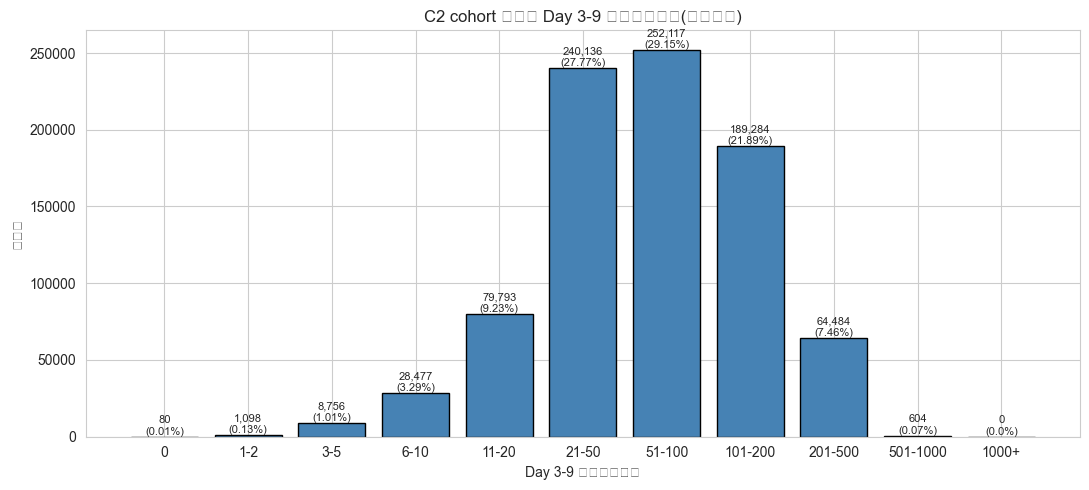

In [5]:
# 自定义分箱
bins = [-0.5, 0.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]
labels = ['0', '1-2', '3-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']

cohort_activity['bucket'] = pd.cut(cohort_activity['day3_9_actions'], bins=bins, labels=labels, right=True)

bucket_dist = cohort_activity['bucket'].value_counts().reindex(labels)
bucket_pct  = (bucket_dist / bucket_dist.sum() * 100).round(2)

dist_df = pd.DataFrame({'users': bucket_dist, 'pct': bucket_pct})
print(dist_df)

# 可视化
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(labels)), bucket_dist.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('Day 3-9 总行为数区间')
ax.set_ylabel('用户数')
ax.set_title('C2 cohort 用户在 Day 3-9 的行为数分布(原始尺度)')
for i, v in enumerate(bucket_dist.values):
    ax.text(i, v, f'{v:,}\n({bucket_pct.values[i]}%)', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

**解读要点**:
- 第一列 `0` 是"Day 3-9 完全 0 行为"的人,这就是**最严格的假死定义**
- 看第一列的数量级:如果占比 < 10% 太少,可能需要放宽定义;如果 > 50% 太多,可能 cohort 选错了
- 看从 `0` 到 `1-2`、`3-5` 的过渡是不是有明显断层 —— 有断层的地方是天然的阈值候选

---

## Part 2.2:Day 1-2 活跃度分布(为分层分析铺垫)

下一步要做"**分层假死分析**":把 cohort 用户按 Day 1-2 活跃度切成 3 层(轻 / 中 / 重),
每层单独定义假死阈值。

这一节只做一件事:**看 Day 1-2 行为数的分布**,从分布形态决定切层的阈值候选。

为什么需要这一步:
- 如果轻度用户(Day 1-2 行为 ≤ 5)占总 cohort 的 70%,那"假死"分析的主体是轻度用户,
  后续阈值要侧重低活跃段
- 如果重度用户占多数,反过来设计
- 初步切分点 5 / 20 是经验猜测,需要根据实际分布形态调整

注意:Day 1-2 是**两天**的合计行为数,所以分位数会比单天看起来高。

In [6]:
# 对 C2 cohort 用户,统计 Day 1-2 总行为数
cohort_day12 = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
),
day1_2_activity AS (
    SELECT user_id, COUNT(*) AS day1_2_actions
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
    GROUP BY user_id
)
SELECT
    c.user_id,
    COALESCE(d.day1_2_actions, 0) AS day1_2_actions
FROM cohort c
LEFT JOIN day1_2_activity d ON c.user_id = d.user_id
""").df()

print(f'C2 cohort 用户总数: {len(cohort_day12):,}')
print()
print('Day 1-2 行为数分位数:')
print(cohort_day12.day1_2_actions.describe(percentiles=[.01, .05, .1, .25, .33, .5, .67, .75, .9, .95, .99]))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

C2 cohort 用户总数: 864,829

Day 1-2 行为数分位数:
count    864829.000000
mean         24.380099
std          28.892428
min           1.000000
1%            1.000000
5%            1.000000
10%           2.000000
25%           5.000000
33%           8.000000
50%          14.000000
67%          25.000000
75%          32.000000
90%          59.000000
95%          81.000000
99%         137.000000
max         501.000000
Name: day1_2_actions, dtype: float64


Day 1-2 行为数分布:
           users    pct
bucket                 
0              0   0.00
1-2       109348  12.64
3-5       110098  12.73
6-10      133512  15.44
11-20     173608  20.07
21-50     222623  25.74
51-100     91117  10.54
101-200    22972   2.66
201-500     1550   0.18
501-1000       1   0.00
1000+          0   0.00

—— 初步三层切分(阈值可调)——
轻度 (Day 1-2 ≤ 5):        219,446 人 (25.37%)
中度 (Day 1-2 6-20):            307,120 人 (35.51%)
重度 (Day 1-2 > 20):        338,263 人 (39.11%)

参考:33% 分位 = 8,67% 分位 = 25(如果想按百分位切层,可用这两个数)


C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\29953100.py:49: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missi

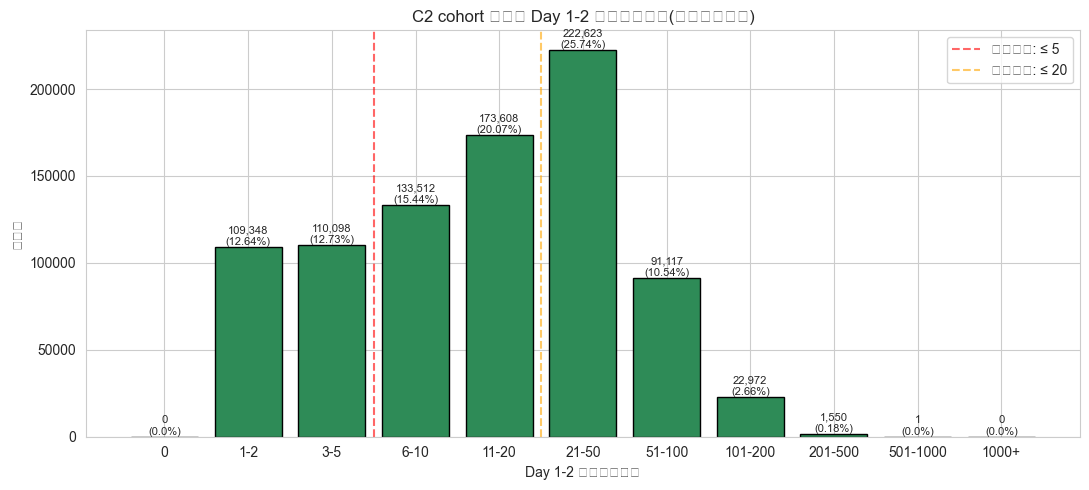

In [7]:
# 直方图 + 初步三层切分
bins = [-0.5, 0.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]
labels = ['0', '1-2', '3-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']

cohort_day12['bucket'] = pd.cut(cohort_day12['day1_2_actions'], bins=bins, labels=labels, right=True)
bucket_dist = cohort_day12['bucket'].value_counts().reindex(labels)
bucket_pct  = (bucket_dist / bucket_dist.sum() * 100).round(2)

dist_df = pd.DataFrame({'users': bucket_dist, 'pct': bucket_pct})
print('Day 1-2 行为数分布:')
print(dist_df)

# 初步三层切分候选
TIER_LIGHT_MAX = 5    # 轻度: Day 1-2 ≤ 5
TIER_MID_MAX   = 20   # 中度: 6-20

n_light = (cohort_day12.day1_2_actions <= TIER_LIGHT_MAX).sum()
n_mid   = ((cohort_day12.day1_2_actions > TIER_LIGHT_MAX) & (cohort_day12.day1_2_actions <= TIER_MID_MAX)).sum()
n_heavy = (cohort_day12.day1_2_actions > TIER_MID_MAX).sum()
total   = len(cohort_day12)

print()
print('—— 初步三层切分(阈值可调)——')
print(f'轻度 (Day 1-2 ≤ {TIER_LIGHT_MAX}):       {n_light:>8,} 人 ({n_light/total*100:>5.2f}%)')
print(f'中度 (Day 1-2 {TIER_LIGHT_MAX+1}-{TIER_MID_MAX}):           {n_mid:>8,} 人 ({n_mid/total*100:>5.2f}%)')
print(f'重度 (Day 1-2 > {TIER_MID_MAX}):       {n_heavy:>8,} 人 ({n_heavy/total*100:>5.2f}%)')

# 33% / 67% 百分位作为参考
p33 = cohort_day12.day1_2_actions.quantile(0.33)
p67 = cohort_day12.day1_2_actions.quantile(0.67)
print()
print(f'参考:33% 分位 = {p33:.0f},67% 分位 = {p67:.0f}(如果想按百分位切层,可用这两个数)')

# 可视化
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(labels)), bucket_dist.values, color='seagreen', edgecolor='black')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('Day 1-2 总行为数区间')
ax.set_ylabel('用户数')
ax.set_title('C2 cohort 用户在 Day 1-2 的行为数分布(决定分层切点)')
for i, v in enumerate(bucket_dist.values):
    ax.text(i, v, f'{v:,}\n({bucket_pct.values[i]}%)', ha='center', va='bottom', fontsize=8)

# 标注初步切分线(对应 bins 边界:5 在 index 2/3 之间;20 在 index 4/5 之间)
ax.axvline(x=2.5, color='red',    linestyle='--', alpha=0.6, label=f'轻度上限: ≤ {TIER_LIGHT_MAX}')
ax.axvline(x=4.5, color='orange', linestyle='--', alpha=0.6, label=f'中度上限: ≤ {TIER_MID_MAX}')
ax.legend()
plt.tight_layout()
plt.show()

**解读要点 & 分层决策辅助**:

1. **分布形态**:
   - 如果是"右偏单峰"(大多数集中在某个低值区间) → cohort 用户活跃度差异不大,分 2 层够了
   - 如果是"双峰"或"宽分布"(明显的分组) → 用户类型差异大,分 3 层有意义

2. **三层占比的判断标准**:
   - **理想**:轻/中/重 大致 1/3、1/3、1/3,每层都有足够样本做独立分析
   - 如果某一层 < 5%,样本太少,要么并入相邻层,要么调整阈值
   - 如果某一层 > 70%,要进一步细分(因为这层内部可能还有差异)

3. **切分阈值不必死守 5 / 20**:
   - 看完直方图后,选**用户数大致均衡 + 业务上能讲清楚**的阈值
   - 也可以用百分位定:比如 33% 分位作为轻度上限,67% 分位作为中度上限

**跑完后告诉我**:
- 三层各自的用户数和占比
- 你看直方图的感觉,切分点要不要调整?
- 如果三层切分确认,我们就基于这个分层进入下一步:**每一层各自的 Day 3-7 衰减分布**(注意是 Day 3-7,排除双 12)

---

## Part 3:双 12 噪声范围验证

回答你的疑问:**双 12 影响是不是只在 Day 8-9?还是从 Day 7 / Day 6 就开始了?**

三个验证角度:

| # | 验证点 | 为什么 |
|---|---|---|
| 3.1 | 每日各行为类型的绝对数与占比 | 双 12 临近,购买意图行为(buy/cart)占比应该上升 |
| 3.2 | 每日 PV → Buy 转化率 | 真正的双 12 来薅一波的人转化率会变高 |
| 3.3 | C2 cohort 用户在 Day 3-9 各天的活跃情况 | 如果 Day 8-9 突然出现一批"假死"用户回流,就是双 12 把他们勾回来了 |

### Part 3.1 每日行为类型的绝对数与占比

In [8]:
daily_behavior = con.sql("""
SELECT
    event_date,
    behavior_type,
    COUNT(*) AS rows
FROM ub
GROUP BY event_date, behavior_type
ORDER BY event_date, behavior_type
""").df()

# 透视成宽表
daily_wide = daily_behavior.pivot(index='event_date', columns='behavior_type', values='rows').fillna(0).astype(int)
daily_wide['total'] = daily_wide.sum(axis=1)
for col in ['pv', 'cart', 'fav', 'buy']:
    daily_wide[f'{col}_pct'] = (daily_wide[col] / daily_wide['total'] * 100).round(3)

print(daily_wide[['pv', 'cart', 'fav', 'buy', 'total']])
print()
print('—— 各行为类型占比 % ——')
print(daily_wide[['pv_pct', 'cart_pct', 'fav_pct', 'buy_pct']])

behavior_type        pv    cart     fav     buy     total
event_date                                               
2017-11-25      9353423  563376  302071  201145  10420015
2017-11-26      9567423  582581  308954  205644  10664602
2017-11-27      9041187  541904  291221  226835  10101147
2017-11-28      8842933  534157  289100  212000   9878190
2017-11-29      9210821  551593  298587  223072  10284073
2017-11-30      9358998  565015  302264  221463  10447740
2017-12-01      9718959  623346  307115  210016  10859436
2017-12-02     12329644  793569  396749  257907  13777869
2017-12-03     12237300  774905  392197  257757  13662159

—— 各行为类型占比 % ——
behavior_type  pv_pct  cart_pct  fav_pct  buy_pct
event_date                                       
2017-11-25     89.764     5.407    2.899    1.930
2017-11-26     89.712     5.463    2.897    1.928
2017-11-27     89.507     5.365    2.883    2.246
2017-11-28     89.520     5.407    2.927    2.146
2017-11-29     89.564     5.364    2.903    2

C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\227214214.py:20: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-4E3A})

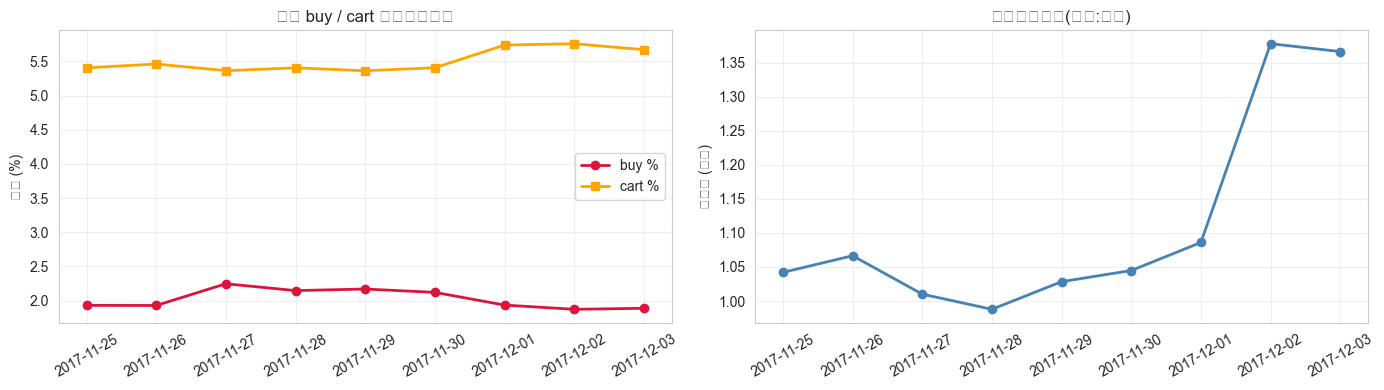

In [9]:
# 可视化:每日 buy / cart 占比的变化趋势
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dates = daily_wide.index.astype(str)

axes[0].plot(dates, daily_wide['buy_pct'], marker='o', color='crimson', linewidth=2, label='buy %')
axes[0].plot(dates, daily_wide['cart_pct'], marker='s', color='orange', linewidth=2, label='cart %')
axes[0].set_title('每日 buy / cart 行为占比变化')
axes[0].set_ylabel('占比 (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates, daily_wide['total'] / 1e7, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('每日总行为数(单位:千万)')
axes[1].set_ylabel('行为数 (千万)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**解读要点**:
- 找 buy / cart 占比的**第一个明显跳变日**,这一天就是双 12 影响的起点
- 总行为数变化跟占比变化是否同步?如果总量先涨、占比后涨,可能是"先来的人多 → 后开始薅"
- 如果某天 buy 占比突然飙高但总量没涨,那是"原班人马突然下单"(典型双 12)

### Part 3.2 每日 PV → Buy 转化率

In [10]:
# 转化率定义(用户级):某天有 PV 的人里,有多少人当天也 buy
con.sql("""
WITH daily_users AS (
    SELECT
        event_date,
        COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'pv')  AS pv_users,
        COUNT(DISTINCT user_id) FILTER (WHERE behavior_type = 'buy') AS buy_users
    FROM ub
    GROUP BY event_date
)
SELECT
    event_date,
    pv_users,
    buy_users,
    ROUND(100.0 * buy_users / pv_users, 3) AS buy_per_pv_user_pct
FROM daily_users
ORDER BY event_date
""").show()

┌────────────┬──────────┬───────────┬─────────────────────┐
│ event_date │ pv_users │ buy_users │ buy_per_pv_user_pct │
│    date    │  int64   │   int64   │       double        │
├────────────┼──────────┼───────────┼─────────────────────┤
│ 2017-11-25 │   686953 │    132622 │              19.306 │
│ 2017-11-26 │   695869 │    136048 │              19.551 │
│ 2017-11-27 │   689260 │    146934 │              21.318 │
│ 2017-11-28 │   688042 │    139845 │              20.325 │
│ 2017-11-29 │   697542 │    146220 │              20.962 │
│ 2017-11-30 │   709586 │    146128 │              20.593 │
│ 2017-12-01 │   718184 │    139971 │               19.49 │
│ 2017-12-02 │   939383 │    174487 │              18.575 │
│ 2017-12-03 │   936431 │    173225 │              18.498 │
└────────────┴──────────┴───────────┴─────────────────────┘



**解读要点**:
- 这个"用户级转化率"(当天浏览的人里有多少同天购买)的跳变日,跟 3.1 的 buy 占比跳变日应该一致
- 如果两个指标跳变日不一致,需要进一步看清楚

### Part 3.3 C2 cohort 用户在 Day 3-9 各天的回流情况

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  event_date  cohort_active_users  cohort_actions
0 2017-11-25               706641        10420015
1 2017-11-26               715516        10664602
2 2017-11-27               646269         9513611
3 2017-11-28               638646         9158468
4 2017-11-29               641800         9423747
5 2017-11-30               647252         9481509
6 2017-12-01               654565         9839786
7 2017-12-02               851087        12433269
8 2017-12-03               848329        12375471


C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 36291 (\N{CJK UNIFIED IDEOGRAPH-8DC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_105760\1263375088.py:35: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-

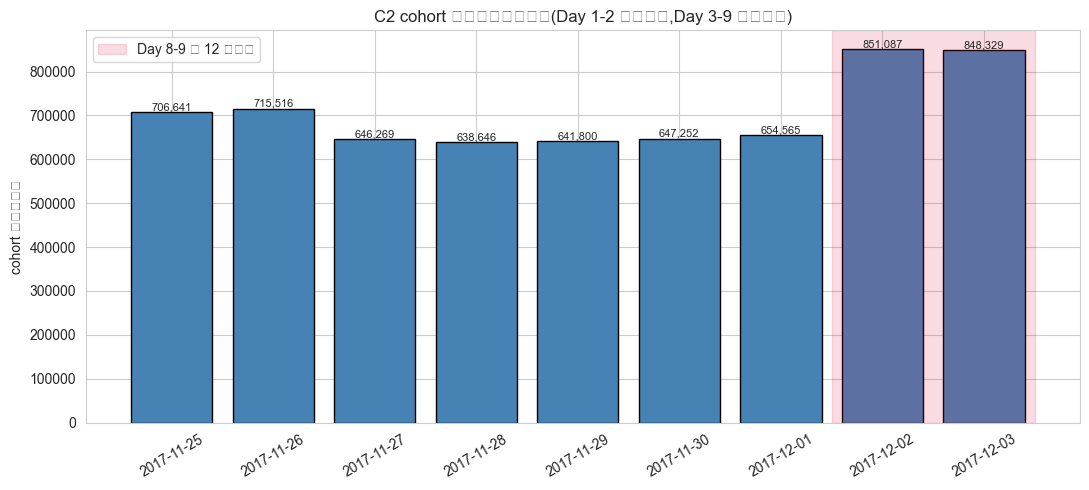

In [11]:
# 对 C2 cohort 用户,看他们 Day 3-9 各天的活跃用户数
# 如果 Day 8 或 Day 9 突然涌现一批"之前在 Day 3-7 没怎么活跃的人",就是双 12 回流

cohort_daily = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
)
SELECT
    u.event_date,
    COUNT(DISTINCT u.user_id) AS cohort_active_users,
    COUNT(*)                  AS cohort_actions
FROM ub u
INNER JOIN cohort c ON u.user_id = c.user_id
WHERE u.event_date BETWEEN DATE '2017-11-25' AND DATE '2017-12-03'
GROUP BY u.event_date
ORDER BY u.event_date
""").df()

print(cohort_daily)

# 可视化
fig, ax = plt.subplots(figsize=(11, 5))
dates = cohort_daily['event_date'].astype(str)
ax.bar(dates, cohort_daily['cohort_active_users'], color='steelblue', edgecolor='black')
ax.set_title('C2 cohort 用户每日活跃人数(Day 1-2 为定义日,Day 3-9 为观察日)')
ax.set_ylabel('cohort 活跃用户数')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(cohort_daily['cohort_active_users']):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
# 标记 Day 8 / Day 9 双 12 嫌疑区
ax.axvspan(6.5, 8.5, alpha=0.15, color='crimson', label='Day 8-9 双 12 嫌疑区')
ax.legend()
plt.tight_layout()
plt.show()

**解读要点**:
- Day 3-7 的活跃数应该是一条"自然衰减曲线"(用户随时间逐渐流失)
- 如果 Day 8 或 Day 9 出现明显的**回升**(不是继续衰减),那就是双 12 把流失用户勾回来了
- 这个回升量越大,说明双 12 把"假死用户"误判为"未假死"的风险越大
- **决策含义**:如果 Day 8-9 回流明显,假死定义应该把观察期截到 Day 3-7,排除双 12 干扰

---

## Part 4:三个问题的初步答案模板(等你填)

> _跑完上面所有 cell 后,在这里写你对三个问题的回答_

### 问题 1:cohort base 选哪个?
> 候选 / 选定 / 理由(基于 Part 1 的数字):

### 问题 2:假死阈值怎么切?
> 看 Part 2 的分布,你倾向切几档?各档的阈值是什么?
> 比如:
> - 严格:Day 3-9 = 0(__人,占比 ___%)
> - 中等:Day 3-9 ≤ ___(__人,占比 ___%)
> - 宽松:Day 3-9 ≤ ___ 且无 cart/fav/buy

### 问题 3:观察期要不要截到 Day 3-7?
> 看 Part 3.1 跳变日 / Part 3.3 回流情况,你的判断:
> - 双 12 影响起点:Day ___
> - 假死分析观察期建议:Day 3-7 / Day 3-9 / 其他

### 跑完上面所有 cell 之后,可以告诉 AI 这三个问题的初步答案,进入切口 A 主分析。
